In [149]:
import sys
import os
# Go up three levels from the notebook's directory (src/concept_creator/src) to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '../../..')) 
# Add the src directory to the path
src_path = os.path.join(project_root, 'src') 
if src_path not in sys.path:
    sys.path.insert(0, src_path)
    
# Optional: Add the specific package's src dir too, sometimes helps resolve sibling imports
# concept_creator_src_path = os.path.join(project_root, 'src', 'concept_creator', 'src')
# if concept_creator_src_path not in sys.path:
#      sys.path.insert(0, concept_creator_src_path)
        
print(f"Project Root: {project_root}")
print(f"Src Path added: {src_path}")
# print(f"Concept Creator Src Path added: {concept_creator_src_path}") # Uncomment if added above
print(f"sys.path[0]: {sys.path[0]}") 

Project Root: /Users/mlapin/Development/personal/NaturalAGI
Src Path added: /Users/mlapin/Development/personal/NaturalAGI/src
sys.path[0]: /Users/mlapin/Development/personal/NaturalAGI/src


In [150]:

import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import random
import networkx as nx
from typing import Any
from dotenv import load_dotenv
from concept_creator.src.logic.start_point_picker import StartPointPicker 
from concept_creator.src.concept_creation_repository import ConceptCreationRepository
from utils.graph_visualizer import visualize_graph

load_dotenv()

True

In [163]:
import time

session_id = "9_2"
uri = os.getenv("NEO4J_DSN")
user = os.getenv("NEO4J_USER")
password = os.getenv("NEO4J_PASSWORD")
repository = ConceptCreationRepository(uri, user, password)

start_time = time.time()
image_ids = repository.get_image_ids_for_session(session_id)
image_graphs = []

for image_id in image_ids:
    image_graphs.append(repository.get_image_graph(image_id))
end_time = time.time()

execution_time_ms = (end_time - start_time) * 1000
print(f"Data loading execution time: {execution_time_ms:.2f} milliseconds")

INFO:root:Initializing ConceptCreationRepository
INFO:root:Database connection established
INFO:root:Getting image IDs for session 9_2


Data loading execution time: 238.49 milliseconds


In [164]:
import time

start_clustering_eps = 0.14
start_clustering_min_samples = int(len(image_graphs) / 10)
start_point_picker = StartPointPicker(image_graphs)

start_time = time.time()
while start_point_picker.get_start_point_characteristic() is None:
    start_clustering_eps += 0.01
    start_point_picker.determine_start_point_characteristic(clustering_eps=start_clustering_eps, clustering_min_samples=start_clustering_min_samples)
end_time = time.time()
execution_time = end_time - start_time

print(f"final start_clustering_eps: {start_clustering_eps}")
print(f"start_clustering_min_samples: {start_clustering_min_samples}")
print(f"Execution time: {execution_time:.3f} seconds")
start_point_characteristic = start_point_picker.get_start_point_characteristic()

all_critical_points = start_point_picker.all_critical_points
clusters = start_point_picker.clusters
valid_clusters = start_point_picker.valid_clusters
final_cluster_points = start_point_picker.final_cluster_points

Start point characteristic not determined yet. Call determine_start_point_characteristic first.
Start point characteristic not determined yet. Call determine_start_point_characteristic first.
Start point characteristic not determined yet. Call determine_start_point_characteristic first.
Start point characteristic not determined yet. Call determine_start_point_characteristic first.
Determined start point characteristic: Label='StartPoint', Centroid=[0.1109375 0.8396875]
final start_clustering_eps: 0.18000000000000005
start_clustering_min_samples: 3
Execution time: 0.010 seconds


In [153]:
# Helper function to get coordinates and labels
def get_plot_data(points_list):
    if not points_list:
        return np.array([]), [], []
    coords = np.array([p.coordinates for p in points_list])
    labels = [p.label for p in points_list]
    graph_ids = [p.graph_id for p in points_list]
    return coords, labels, graph_ids

In [154]:
# Helper function for distinct colors
def get_distinct_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        # Simple way to generate somewhat distinct colors, can be improved
        colors.append(plt.cm.viridis(hue)) 
    random.shuffle(colors) # Shuffle to avoid similar adjacent colors if using sequential hues
    # Add a color for noise if DBSCAN is used
    colors.append((0.5, 0.5, 0.5, 1.0)) # Gray for noise (-1)
    return colors

In [155]:
# Function to highlight the start point on a graph
def highlight_start_point(graph: nx.Graph, start_node_id: Any, ax: plt.Axes = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 10))
    
    # First visualize the whole graph
    visualize_graph(graph, ax=ax)
    
    if start_node_id is None:
        ax.set_title("No start point found")
        return ax
    
    # Get the node position
    node_data = graph.nodes[start_node_id]
    
    # For regular points, get x and y coordinates
    if 'x' in node_data and 'y' in node_data:
        x_min = node_data['x']['min'] if isinstance(node_data['x'], dict) and 'min' in node_data['x'] else node_data['x']
        x_max = node_data['x']['max'] if isinstance(node_data['x'], dict) and 'max' in node_data['x'] else node_data['x']
        y_min = node_data['y']['min'] if isinstance(node_data['y'], dict) and 'min' in node_data['y'] else node_data['y']
        y_max = node_data['y']['max'] if isinstance(node_data['y'], dict) and 'max' in node_data['y'] else node_data['y']
        
        x = (x_min + x_max) / 2
        y = (y_min + y_max) / 2
        
        # Highlight the start point with a star marker
        ax.scatter(x, y, color='red', s=500, marker='*', zorder=10, 
                  edgecolor='black', linewidth=1.5)
        
        # Add a label for the start point
        labels = node_data.get('labels', [])
        label_str = ', '.join(str(label) for label in labels)
        ax.annotate(f"START POINT\n{label_str}", (x, y), 
                   xytext=(15, 15), textcoords='offset points',
                   bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", alpha=0.8),
                   arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))
    
    return ax

# --- Visualization 1: All Critical Points ---

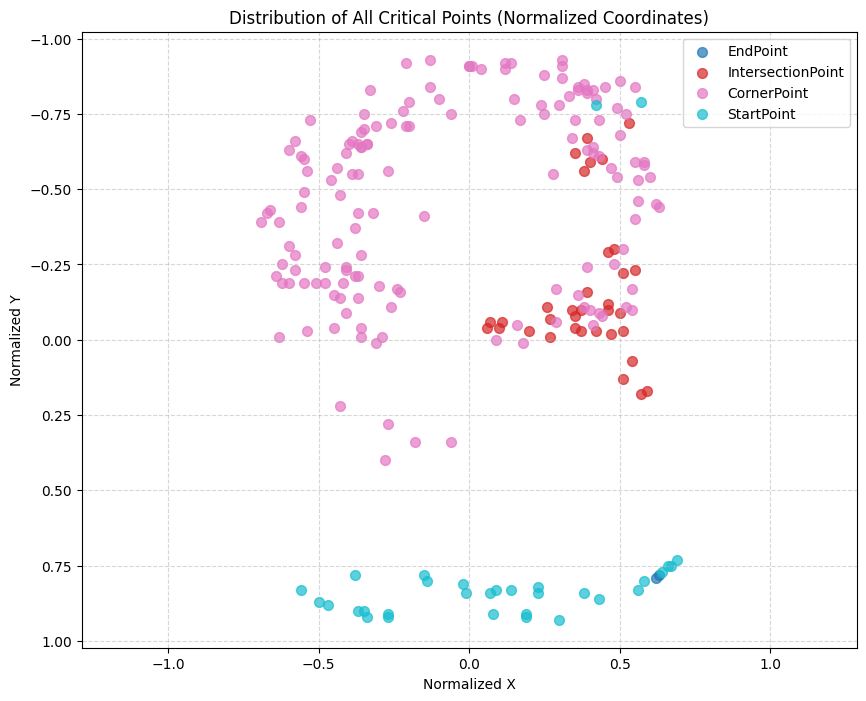

In [156]:
plt.figure(figsize=(10, 8))
coords, labels, _ = get_plot_data(all_critical_points)
point_types = list(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(point_types)))
color_map = {label: color for label, color in zip(point_types, colors)}

for label_type in point_types:
    type_indices = [i for i, lbl in enumerate(labels) if lbl == label_type]
    if type_indices:
        plt.scatter(coords[type_indices, 0], coords[type_indices, 1], 
                    color=color_map[label_type], label=label_type, alpha=0.7, s=50)

plt.title('Distribution of All Critical Points (Normalized Coordinates)')
plt.xlabel('Normalized X')
plt.ylabel('Normalized Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().invert_yaxis() # Often useful for image-like coordinates
plt.axis('equal')
plt.show()

# --- Visualization 2: Clustering Results ---

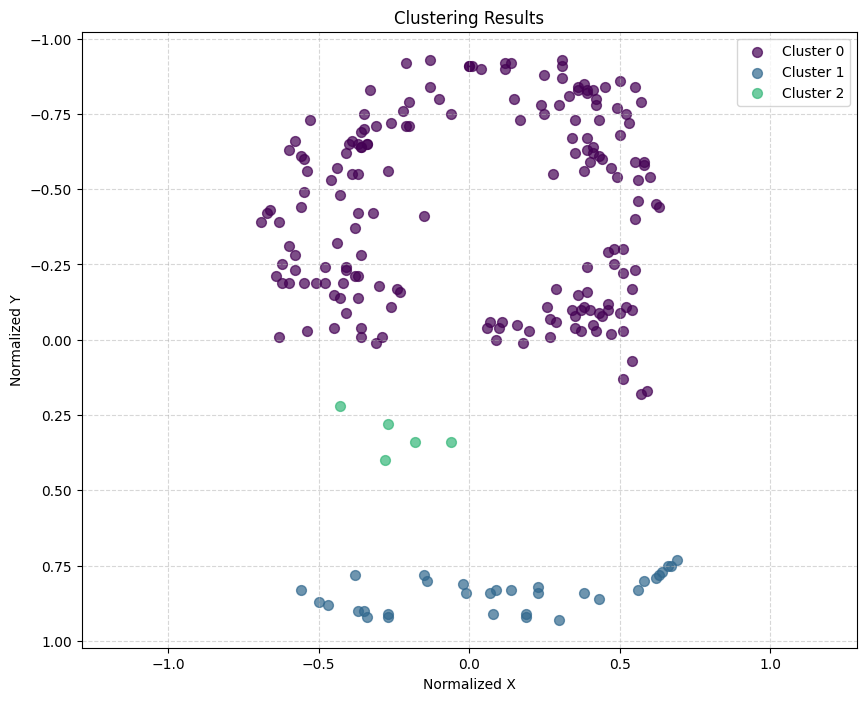

In [157]:
plt.figure(figsize=(10, 8))
cluster_ids = list(clusters.keys())
# Handle potential noise cluster (-1) with DBSCAN
num_clusters = len(cluster_ids) if -1 not in cluster_ids else len(cluster_ids) -1
cluster_colors = get_distinct_colors(num_clusters) # Get N distinct colors + 1 for noise

# Map cluster ID to a color (handle noise explicitly)
color_dict = {cid: cluster_colors[i] for i, cid in enumerate(sorted([c for c in cluster_ids if c != -1]))}
noise_color = cluster_colors[-1] # Last color is for noise

all_points_in_clusters = []
for cid, points in clusters.items():
    all_points_in_clusters.extend(points)

coords, _, _ = get_plot_data(all_points_in_clusters) # Use only points that are part of clusters

cluster_labels_for_plot = []
point_coords_for_plot = []
cluster_id_map = {} # Keep track of which cluster id maps to which point index

idx_counter = 0
for cid, points in clusters.items():
     if not points: continue
     cluster_id_map[cid] = list(range(idx_counter, idx_counter + len(points)))
     idx_counter += len(points)
     
     point_coords_for_plot.extend([p.coordinates for p in points])
     cluster_labels_for_plot.extend([cid] * len(points))
     
point_coords_for_plot = np.array(point_coords_for_plot)

for cid in sorted(cluster_id_map.keys()):
    indices = cluster_id_map[cid]
    color = color_dict.get(cid, noise_color) # Use noise color if cid is -1 or not found
    label = f'Cluster {cid}' if cid != -1 else 'Noise'
    if indices: # Check if there are points for this cluster id
         plt.scatter(point_coords_for_plot[indices, 0], point_coords_for_plot[indices, 1], 
                     color=color, label=label, alpha=0.7, s=50)

plt.title('Clustering Results')
plt.xlabel('Normalized X')
plt.ylabel('Normalized Y')
# Avoid overcrowding legend if too many clusters
if len(cluster_ids) < 15:
    plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()
plt.axis('equal')
plt.show()

# --- Visualization 3: Filtered Valid Clusters ---

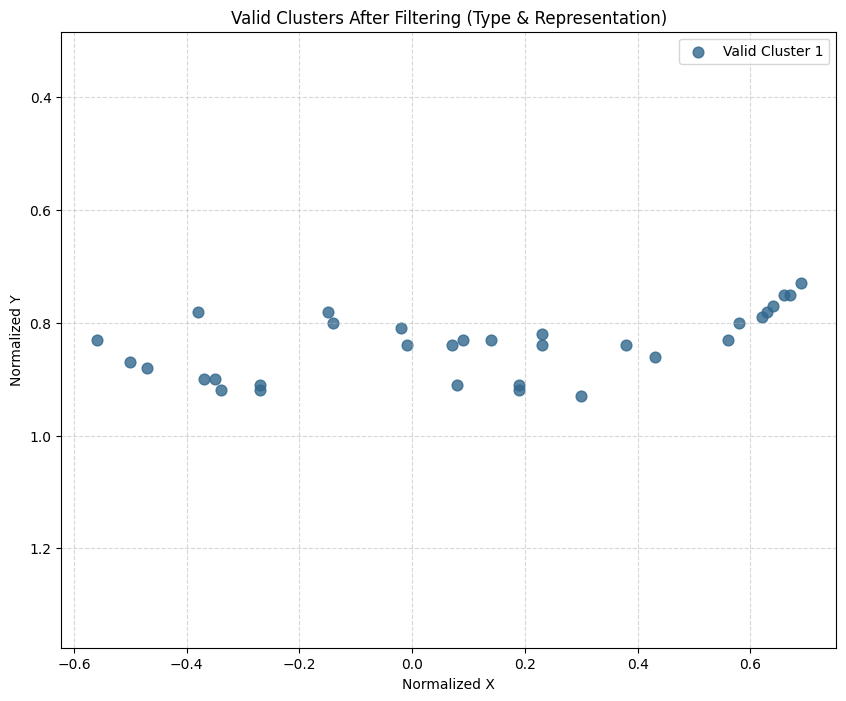

In [158]:
plt.figure(figsize=(10, 8))

if not valid_clusters:
     plt.text(0.5, 0.5, 'No valid clusters found after filtering', 
              horizontalalignment='center', verticalalignment='center', 
              transform=plt.gca().transAxes)
else:
     # Use the same color mapping as the previous plot for consistency
     for cid, points in valid_clusters.items():
          coords, _, _ = get_plot_data(points)
          color = color_dict.get(cid, noise_color) # Should always find color here
          label = f'Valid Cluster {cid}'
          if coords.size > 0: # Check if coords is not empty
            plt.scatter(coords[:, 0], coords[:, 1], 
                        color=color, label=label, alpha=0.8, s=60)

     plt.title('Valid Clusters After Filtering (Type & Representation)')
     plt.xlabel('Normalized X')
     plt.ylabel('Normalized Y')
     plt.legend()
     plt.grid(True, linestyle='--', alpha=0.5)
     plt.gca().invert_yaxis()
     plt.axis('equal')
plt.show()

# --- Visualization 4: Final Selected Cluster and Start Point ---

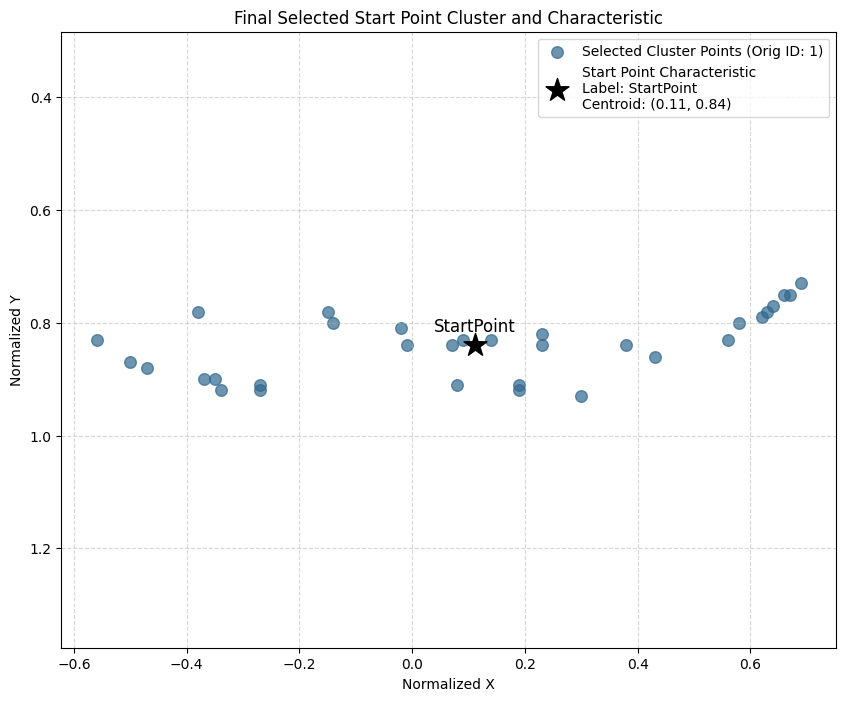

In [159]:
plt.figure(figsize=(10, 8))

if not final_cluster_points:
    plt.text(0.5, 0.5, 'No final cluster selected', 
              horizontalalignment='center', verticalalignment='center', 
              transform=plt.gca().transAxes)
else:
    coords, _, _ = get_plot_data(final_cluster_points)
    
    # Find the original cluster ID for color consistency (optional but nice)
    final_cluster_id = -2 # Default if not found
    for cid, points in valid_clusters.items():
         # Simple check based on first point's identity, assumes points are objects
         if points and final_cluster_points and points[0] is final_cluster_points[0]: 
              final_cluster_id = cid
              break
    
    color = color_dict.get(final_cluster_id, 'red') # Use red if ID lookup fails

    if coords.size > 0:
        plt.scatter(coords[:, 0], coords[:, 1], 
                    color=color, label=f'Selected Cluster Points (Orig ID: {final_cluster_id})', 
                    alpha=0.7, s=70)

    if start_point_characteristic:
        dominant_label, centroid = start_point_characteristic
        plt.scatter(centroid[0], centroid[1], 
                    color='black', marker='*', s=300, 
                    label=f'Start Point Characteristic\nLabel: {dominant_label}\nCentroid: ({centroid[0]:.2f}, {centroid[1]:.2f})', 
                    zorder=5) # Ensure star is on top
        plt.annotate(f'{dominant_label}', (centroid[0], centroid[1]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12)


    plt.title('Final Selected Start Point Cluster and Characteristic')
    plt.xlabel('Normalized X')
    plt.ylabel('Normalized Y')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.gca().invert_yaxis()
    plt.axis('equal')
plt.show()

Start Point Characteristic:
- Dominant Label: StartPoint
- Centroid: (0.11, 0.84)


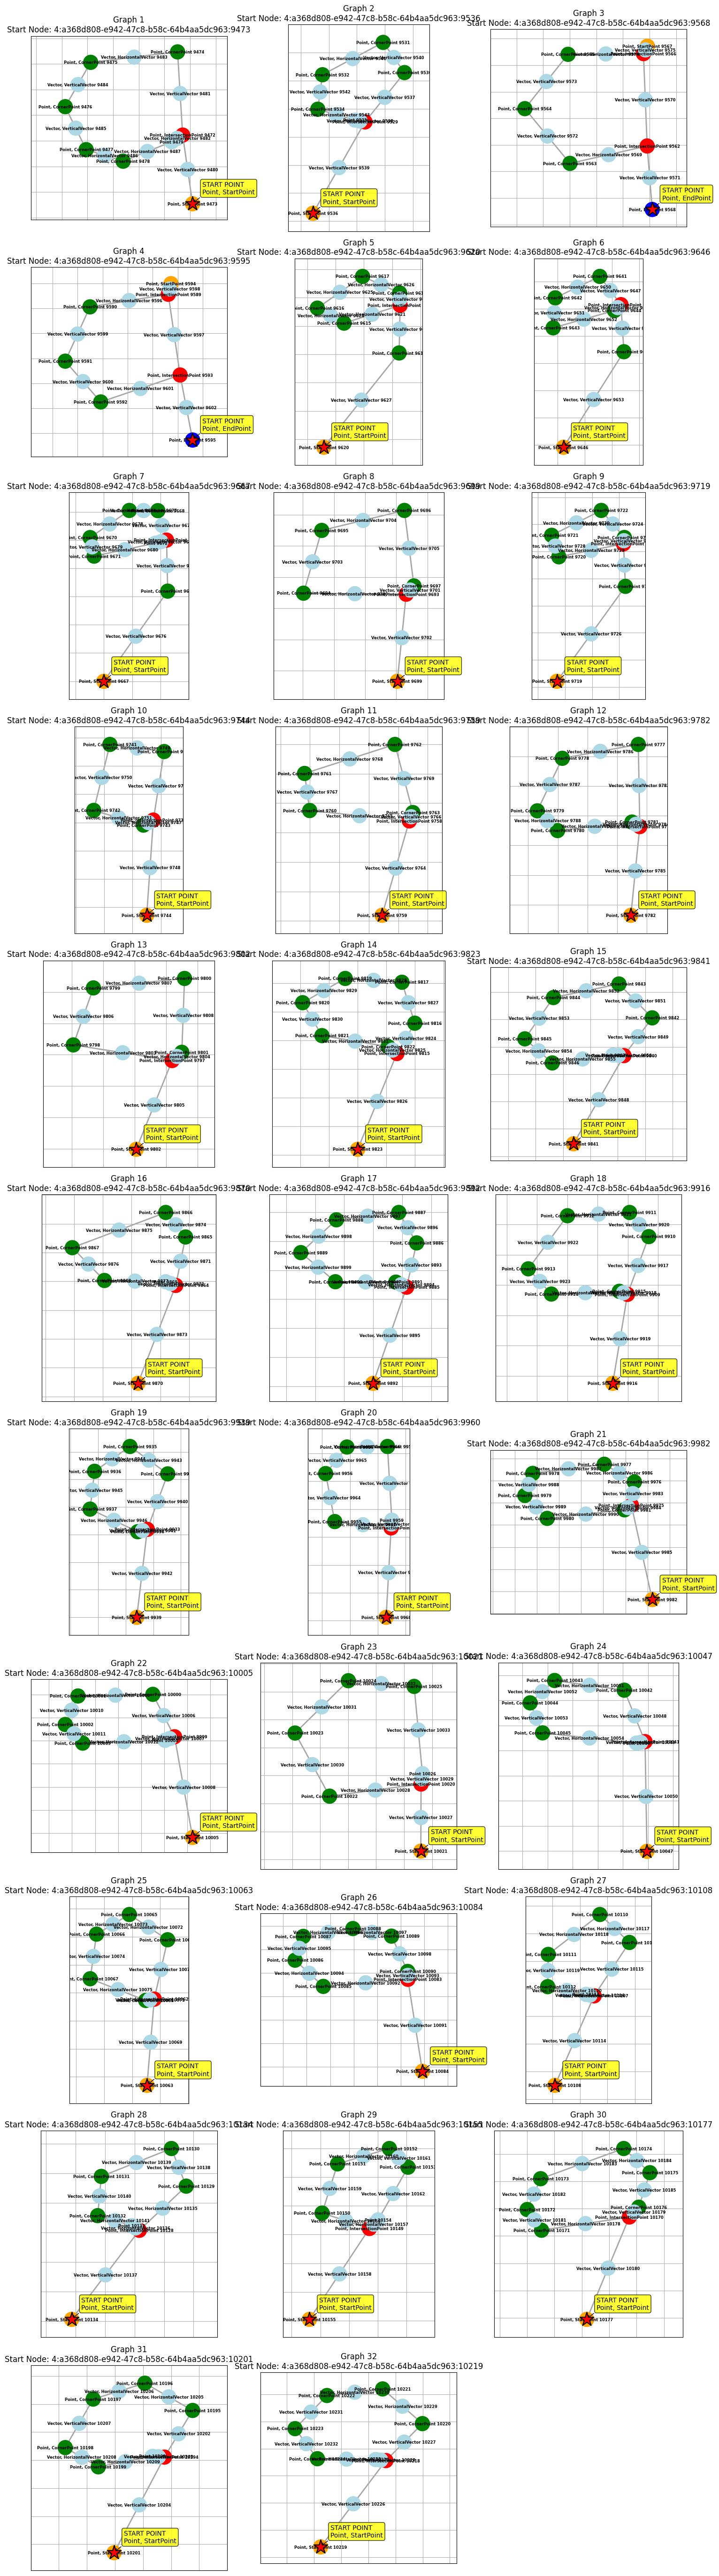

In [160]:
# Main visualization process
if not image_graphs:
    print("No sample graphs provided")

if start_point_characteristic:
    dominant_label, centroid = start_point_characteristic
    print(f"Start Point Characteristic:")
    print(f"- Dominant Label: {dominant_label}")
    print(f"- Centroid: ({centroid[0]:.2f}, {centroid[1]:.2f})")
else:
    print("No start point characteristic determined")

# Now visualize each graph with its selected start point in a grid layout
num_graphs = len(image_graphs)
if num_graphs > 0:
    # Define grid layout with 3 columns
    cols = 3
    rows = (num_graphs + cols - 1) // cols  # Ceiling division to get number of rows needed
    
    fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    
    # Flatten the axes array for easy indexing
    axs = axs.flatten() if rows > 1 or cols > 1 else [axs]
    
    for i, graph in enumerate(image_graphs):
        if i < num_graphs:  # Only process actual graphs
            start_node_id = start_point_picker.get_start_point_for_graph(graph)
            highlight_start_point(graph, start_node_id, ax=axs[i])
            
            # Set title with graph index
            axs[i].set_title(f"Graph {i+1}\nStart Node: {start_node_id}")
    
    # Hide any unused subplots
    for j in range(num_graphs, rows * cols):
        axs[j].axis('off')
    
    plt.tight_layout()